In [1]:
import tensorflow as tf #platform to perform machine learning task
from tensorflow import keras #APIs that provide easy and efficient design and training of deep learning models
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

### without hidden layer

In [2]:
(X_train,y_train) , (X_test,y_test) = keras.datasets.mnist.load_data()  #load the data from keras and split it to xtrain and ytrain

In [3]:
len(X_train)

60000

In [4]:
len(X_test)

10000

In [5]:
X_train[0].shape   #shape of the first row

(28, 28)

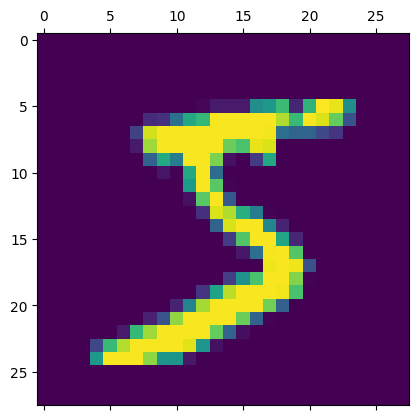

In [6]:
plt.matshow(X_train[0])

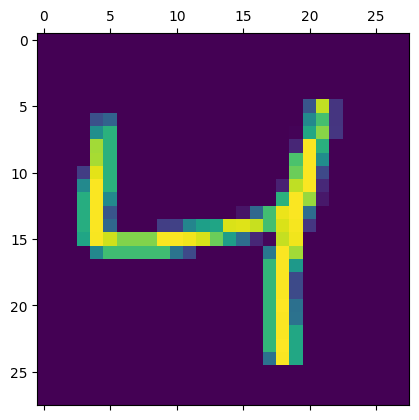

In [7]:
plt.matshow(X_train[2])

In [8]:
X_train = X_train/255 #here we are normalizing to get the output in range of 0 and 1
X_test = X_test/255   #divided by 255 coz the pixel intensity value is bteween 0-255 i.e every cell divided by 255

In [9]:
X_train_flattened = X_train.reshape(len(X_train), 28*28) #convert 2d to 1d
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [10]:
X_train_flattened.shape

(60000, 784)

In [11]:
X_test_flattened.shape

(10000, 784)

In [12]:
#creating neural network,where sequential method is used
model1 = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,) ,activation = 'sigmoid') #defining layers 10 represents 10 nodes or neurons,input_shape is the length
])  

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model1.compile(optimizer= 'adam' , loss='sparse_categorical_crossentropy' ,metrics=['accuracy']) #loss=measured quantity during training which must be least, sparse coz ooutputs are nos and are in category of 0-9,accuracy is on what we want just the model on what basis

In [14]:
model1.fit(X_train_flattened,y_train, epochs =5) #train the model, epochs=1dats forword and backward pass is one epochs

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8759 - loss: 0.4727
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9147 - loss: 0.3036
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9207 - loss: 0.2835
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9233 - loss: 0.2731
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9255 - loss: 0.2661


In [15]:
model1.evaluate (X_test_flattened ,y_test) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9256 - loss: 0.2658


[0.265849232673645, 0.925599992275238]

In [16]:
predicted = model1.predict(X_test_flattened) #predict the model.give all image one by one and the neuron generates a possile figure for every image provided for prediction
predicted[0]  #predict for the 1st sample

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([1.3857242e-02, 2.4360574e-07, 5.0841041e-02, 9.5343924e-01,
       1.1594263e-03, 9.3844987e-02, 1.1620317e-06, 9.9978215e-01,
       6.8174750e-02, 5.9109664e-01], dtype=float32)

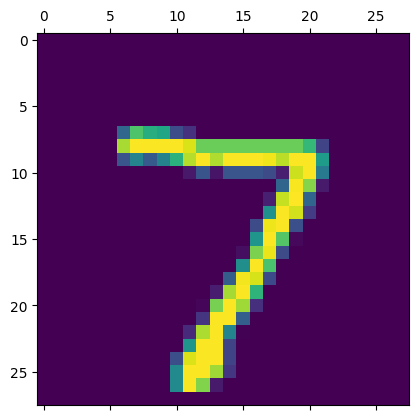

In [17]:
plt.matshow(X_test[0])

In [18]:
import numpy as np
np.argmax(predicted[0])  #here it shows the maximum of the 10 neurons output for the 1st entry

np.int64(7)

### with hidden layer

In [19]:
#here 300 shows the no of neurons which is the hidden layers and the second is the output layer
model2 = keras.Sequential([
    keras.layers.Dense(300, input_shape=(784,) ,activation = 'relu'),keras.layers.Dense(10 ,activation = 'sigmoid') #defining layers 10 represents 10 nodes or neurons,input_shape is the length
]) 

In [20]:
model2.compile(optimizer= 'adam' , loss='sparse_categorical_crossentropy' ,metrics=['accuracy']) #loss=measured quantity during training which must be least, sparse coz ooutputs are nos and are in category of 0-9,accuracy is on what we want just the model on what basis

In [21]:
model2.fit(X_train_flattened,y_train, epochs =5) #train the model, epochs=1dats forword and backward pass is one epochs
model2.evaluate (X_test_flattened ,y_test) 

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9371 - loss: 0.2161
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - accuracy: 0.9740 - loss: 0.0882
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9816 - loss: 0.0588
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9871 - loss: 0.0416
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9907 - loss: 0.0305
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9773 - loss: 0.0747


[0.07468914240598679, 0.9772999882698059]